In [1]:
from sklearn.metrics import *
import numpy as np

In [9]:
import pandas as pd
from ESRNN import ESRNN
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction




# Load your time series data
# Ensure your dataframe has 'unique_id', 'ds' (date), and 'y' (value) columns
df = pd.read_excel('preprocessedBelgeler/ES_RNN Adjusted.xlsx')
df['unique_id'] = df['unique_id'].astype(str)



# Remove rows where y is zero
df['y'] = df['y'].replace(0, 1)

zero_mask = df['y'] == 0
num_zeros = zero_mask.sum()

# 0 olan yerleri 50 ile 150 arasında rastgele sayılarla değiştir
df.loc[zero_mask, 'y'] = np.random.randint(50, 150, size=num_zeros)
df = df.sort_values(by=["unique_id", "ds"])

#df['y'] = 50*df['y']

# Split data into training and testing sets

#train_df = df[(df['ds'] >= '2020-01-01') & (df['ds'] <= '2023-12-31')]
train_df = df[df['ds'] <= '2023-12-31']
test_df = df[df['ds'] > '2023-12-31']


# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable


model = ESRNN(max_epochs=5, 
              # frequency of computing and reporting this loss
              freq_of_test=1, 
              batch_size=16, 
              
              # customize things around the learning rate
              learning_rate=0.001, per_series_lr_multip=0.5,
              lr_scheduler_step_size=7, lr_decay=0.5, 
              
              gradient_clipping_threshold=5, 
              rnn_weight_decay=0.0, noise_std=0.001, 
              level_variability_penalty=30, 
              
              # for probabilistic forecasting
              testing_percentile=10, training_percentile=50,
              
              ensemble=True, max_periods=70, 
              seasonality=[12], input_size=12, output_size=16,
              cell_type='LSTM', state_hsize=40, 
               
              add_nl_layer=False,
              random_seed=1, device='cpu')




# Split into X and y for training and testing
X_train_df = train_df[X_columns]
y_train_df = train_df[y_column]

print(y_train_df)
X_test_df = test_df[X_columns]
y_test_df = test_df[y_column]


"""
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)
"""

# Fit the model
model.fit(X_train_df, y_train_df)





print(X_test_df)
y_hat = model.predict(X_test_df)
print(y_hat)


      unique_id         ds     y
26141         1 2018-01-01   1.0
1612          1 2018-02-01  30.0
26142         1 2018-03-01   1.0
26143         1 2018-04-01   1.0
6228          1 2018-05-01  50.0
...         ...        ...   ...
43150       999 2023-08-01   1.0
43151       999 2023-09-01   1.0
43152       999 2023-10-01   1.0
43153       999 2023-11-01   1.0
43154       999 2023-12-01   1.0

[95256 rows x 3 columns]
Infered frequency: MS
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 2.18603
Training loss (50 prc): 50.74176
========= Epoch 1 finished =========
Training time: 2.16876
Training loss (50 prc): 50.47261
========= Epoch 2 finished =========
Training time: 2.19487
Training loss (50 prc): 50.28239
========= Epoch 3 finished =========
Training time: 2.26208
Training loss (50 prc): 50.02652
========= Epoch 4 finished =========
Training time: 2.20345
Training loss (50 prc): 49.91517
Train finished! 

      unique_id         

In [10]:
comparison_df = y_hat.merge(y_test_df, on=['unique_id', 'ds'], how='left')
print(comparison_df)
def save_datasets(comparison_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    comparison_df.to_csv(f"{folder_path}comparison_df.csv", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Save Data Before Running the Model
save_datasets(comparison_df)

      unique_id         ds      x      y_hat      y
0             1 2024-01-01  Other  32.078789   34.5
1             1 2024-02-01  Other  35.958050    1.0
2             1 2024-03-01  Other  10.678205    1.0
3             1 2024-04-01  Other   8.040522  140.0
4             1 2024-05-01  Other  10.067657   70.0
...         ...        ...    ...        ...    ...
21163       999 2024-12-01  Other   1.089327    1.0
21164       999 2025-01-01  Other   1.392573    1.0
21165       999 2025-02-01  Other   0.525544    1.0
21166       999 2025-03-01  Other   0.481423    1.0
21167       999 2025-04-01  Other   0.473014    1.0

[21168 rows x 5 columns]
Data saved in '/Users/cankocak/Desktop/Spring25/' before running the model.


In [11]:
print(y_test_df['y'])

mae = mean_absolute_error(y_test_df['y'], y_hat['y_hat'])
mape = mean_absolute_percentage_error(y_test_df['y'], y_hat['y_hat'])

print(f"\n📉 MAE: {mae:.4f}")
print(f"📊 MAPE: {mape:.2f}%")

1189      34.5
26163      1.0
4288       1.0
5967     140.0
7446      70.0
         ...  
43166      1.0
43167      1.0
43168      1.0
43169      1.0
43170      1.0
Name: y, Length: 21168, dtype: float64

📉 MAE: 27.4021
📊 MAPE: 2.21%


In [12]:
import pandas as pd
import numpy as np
from ESRNN.utils_evaluation import evaluate_prediction_owa

# 🔧 1. Tipleri eşitle
for df in [y_hat, y_test_df, y_train_df]:
    df['unique_id'] = df['unique_id'].astype(str)
    df['ds'] = pd.to_datetime(df['ds'])

# 🔧 2. Sadece gerekli kolonlar
y_hat_clean = y_hat[['unique_id', 'ds', 'y_hat']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
y_test_clean = y_test_df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
y_train_clean = y_train_df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

# 🔍 3. Uyumlu index ve tip kontrolü (hata almamak için)
assert 'y_hat' in y_hat_clean.columns
assert y_hat_clean['unique_id'].is_monotonic_increasing
assert y_test_clean['unique_id'].is_monotonic_increasing
assert y_hat_clean.shape[0] == y_test_clean.shape[0], "Tahmin ve gerçek test verisi uyumsuz!"

# ✅ 4. Evaluation çağrısı
final_owa, final_mase, final_smape = evaluate_prediction_owa(
    y_hat_df=y_hat_clean,
    y_train_df=y_train_clean,
    X_test_df=X_test_df,
    y_test_df=y_test_clean,
    naive2_seasonality=12
)

# 🎯 5. Sonuçları yazdır
print("\n✅ Evaluation Results:")
print(f"📦 OWA   : {final_owa:.4f}")
print(f"📏 MASE  : {final_mase:.4f}")
print(f"📈 sMAPE : {final_smape:.2f}%")




/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_98493/518542714.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['unique_id'] = df['unique_id'].astype(str)
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_98493/518542714.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ds'] = pd.to_datetime(df['ds'])
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_98493/518542714.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

AttributeError: module 'numpy' has no attribute 'asscalar'

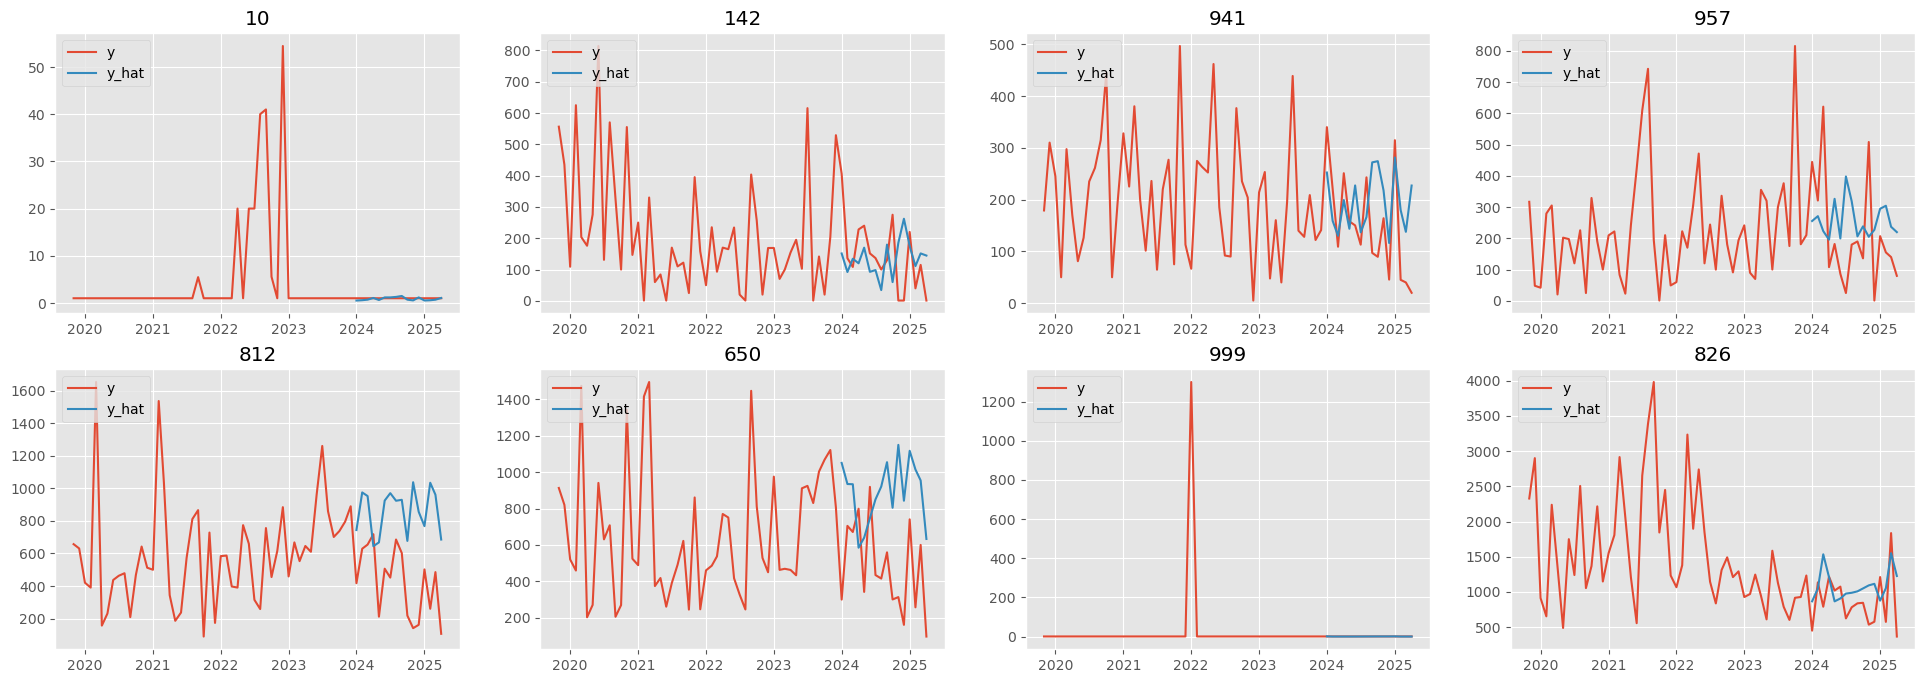

In [14]:
unique_ids = ['10', '957', '650', '142', '826', '812', '941', '999']

plot_preds = pd.concat([y_train_df.groupby('unique_id').tail(50), 
                        y_test_df],  sort=True)

plot_grid_prediction(plot_preds, y_hat,  unique_ids=unique_ids)

In [ ]:
# Function to save datasets
def save_datasets(X_train_df, y_train_df, X_test_df, y_test_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    X_train_df.to_csv(f"{folder_path}X_train_df.csv", index=False)
    y_train_df.to_csv(f"{folder_path}y_train_df.csv", index=False)
    X_test_df.to_csv(f"{folder_path}X_test_df.csv", index=False)
    y_test_df.to_csv(f"{folder_path}y_test_df.csv", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Ensure Data Is Clean Before Saving
X_train_df = X_train_df.dropna().reset_index(drop=True)
y_train_df = y_train_df.dropna().reset_index(drop=True)
X_test_df = X_test_df.dropna().reset_index(drop=True)
y_test_df = y_test_df.dropna().reset_index(drop=True)

# Save Data Before Running the Model
save_datasets(X_train_df, y_train_df, X_test_df, y_test_df)

In [ ]:
# Generate forecasts
forecasts = model.predict(X_test_df, y_test_df)
print(forecasts[:1000])

In [64]:
from ESRNN import ESRNN
from ESRNN.m4_data import *
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction


X_train_df, y_train_df, X_test_df, y_test_df = prepare_m4_data( dataset_name="Monthly", 
   directory="/Users/cankocak/Desktop/Spring25/INDR491/m4 Dataset", 
   num_obs=414)
print(y_train_df.head(50000))

# Initialize the ESRNN model
model = ESRNN(max_epochs=5, 
              # frequency of computing and reporting this loss
              freq_of_test=1, 
              batch_size=32, 
              
              # customize things around the learning rate
              learning_rate=0.02, per_series_lr_multip=0.5,
              lr_scheduler_step_size=7, lr_decay=0.5, 
              
              gradient_clipping_threshold=50, 
              rnn_weight_decay=0.0, noise_std=0.001, 
              level_variability_penalty=30, 
              
              # for probabilistic forecasting
              testing_percentile=50, training_percentile=50,
              
              ensemble=True, max_periods=371, 
              seasonality=[12], input_size=12, output_size=24,
              cell_type='LSTM', state_hsize=40, 
              dilations=[[1, 4, 24, 168]], 
              add_nl_layer=False,
              random_seed=1, device='cpu')

# Fit the model
model.fit(X_train_df, y_train_df)

#Predict on test set
y_hat_df = model.predict(X_test_df)
print(y_hat_df)
# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(y_hat_df, y_train_df, 
                                                             X_test_df, y_test_df,
                                                             naive2_seasonality=24)



      unique_id         ds       y
0            M1 1970-01-31  8000.0
1            M1 1970-02-28  8350.0
2            M1 1970-03-31  8570.0
3            M1 1970-04-30  7700.0
4            M1 1970-05-31  7080.0
...         ...        ...     ...
49995      M208 1980-10-31   649.0
49996      M208 1980-11-30   651.0
49997      M208 1980-12-31   655.0
49998      M208 1981-01-31   660.0
49999      M208 1981-02-28   666.0

[50000 rows x 3 columns]
Infered frequency: M
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 0.60018
Training loss (50 prc): 0.29084
========= Epoch 1 finished =========
Training time: 0.62344
Training loss (50 prc): 0.30039
========= Epoch 2 finished =========
Training time: 0.6354
Training loss (50 prc): 0.27509
========= Epoch 3 finished =========
Training time: 0.65004
Training loss (50 prc): 0.26180
========= Epoch 4 finished =========
Training time: 0.52492
Training loss (50 prc): 0.25793
Train finished! 

     

AttributeError: module 'numpy' has no attribute 'asscalar'

In [36]:
import pandas as pd
import numpy as np

# Load existing dataset
file_path = "preprocessedBelgeler/filled_ES_RNN.xlsx"  # Update with your actual file path
df = pd.read_excel(file_path)

# Convert 'ds' to datetime
df['ds'] = pd.to_datetime(df['ds'])

# Find the earliest date in the dataset
earliest_date = df['ds'].min()

# Generate 300 months back from the earliest date
months_back = 300
new_dates = pd.date_range(end=earliest_date, periods=months_back, freq='MS')

# Create a new DataFrame for expanded data
expanded_data = []

for unique_id in df['unique_id'].unique():
    x_value = df[df['unique_id'] == unique_id]['x'].iloc[0]  # Preserve 'x' value
    for date in new_dates:
        random_y = np.random.randint(1, 500)  # Generate a random y value
        expanded_data.append([date, unique_id, random_y, x_value])

# Convert list to DataFrame
df_expanded = pd.DataFrame(expanded_data, columns=['ds', 'unique_id', 'y', 'x'])

# Combine with original dataset
df_final = pd.concat([df, df_expanded]).drop_duplicates(subset=['ds', 'unique_id']).sort_values(['unique_id', 'ds'])

# Save to new file
df_final.to_excel("preprocessedBelgeler/expanded_data.xlsx", index=False)

print("Dataset expanded successfully. Check 'expanded_data.xlsx'")


Dataset expanded successfully. Check 'expanded_data.xlsx'
